# Análise Exploratória dos Dados - Telco Customer Churn

Base de dados para a rotatividade de clientes da empresa de telecomunicações contêm informações sobre uma empresa fictícia que forneceu serviços de telefonia fixa e internet para 7.043 clientes na Califórnia no terceiro trimestre. Indicam quais clientes cancelaram, permaneceram ou assinaram o serviço. Diversos dados demográficos importantes são incluídos para cada cliente, bem como uma pontuação de satisfação, uma pontuação de rotatividade e um índice de valor vitalício do cliente (CLTV).

Cada linha representa um cliente, e cada coluna contém os atributos do cliente descritos na coluna Metadados.

O conjunto de dados inclui informações sobre:

Clientes que cancelaram o serviço no último mês – esta coluna chama-se Churn (Cancelamento de Clientes).
Serviços contratados por cada cliente: telefone, múltiplas linhas, internet, segurança online, backup online, proteção de dispositivos, suporte técnico e streaming de TV e filmes.
Informações da conta do cliente – tempo de relacionamento, contrato, forma de pagamento, faturamento eletrônico, valores mensais e valor total a pagar.
Informações demográficas sobre os clientes – sexo, faixa etária e se eles têm cônjuge ou dependentes.

## Objetivos

- Realizar Análise Exploratória de Dados (EDA) completa
- Identificar e tratar anomalias, outliers e missing values
- Aplicar técnicas de preparação de dados

=================== Atividades posteriores ====================

- Configurar e usar MLFlow para rastreamento de experimentos
- Experimentar com diferentes algoritmos e hiperparâmetros
- Comparar resultados de múltiplos experimentos
- Criar um MVP (Minimum Viable Product) de modelo



# 1.0 Configuração do Ambiente

In [1]:
# Bibliotecas utilizadas 
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Estatística
from scipy import stats


# Carregando os dados do dataset


## 📊 Data Dictionary – Customer Churn Dataset

### 🔹 Identificação do Cliente
| Coluna | Tipo | Descrição | Valores |
|--------|------|----------|--------|
| CustomerID | string | Identificador único do cliente | - |
| Count | int | Contador usado para agregações | - |

### 🔹 Dados Demográficos
| Coluna | Tipo | Descrição | Valores |
|--------|------|----------|--------|
| Gender | string | Gênero do cliente | Male, Female |
| Age | int | Idade do cliente | - |
| SeniorCitizen | boolean | Cliente tem 65 anos ou mais | Yes, No |
| Married | boolean | Cliente é casado | Yes, No |
| Dependents | boolean | Possui dependentes | Yes, No |
| NumberOfDependents | int | Número de dependentes | - |
| Under30 | boolean | Cliente tem menos de 30 anos | Yes, No |

### 🔹 Localização
| Coluna | Tipo | Descrição | Valores |
|--------|------|----------|--------|
| Country | string | País de residência | - |
| State | string | Estado de residência | - |
| City | string | Cidade de residência | - |
| ZipCode | string | CEP | - |
| Lat Long | string | Latitude e Longitude | - |
| Latitude | decimal | Latitude | - |
| Longitude | decimal | Longitude | - |
| Population | int | População estimada da região | - |

### 🔹 Tempo e Relacionamento
| Coluna | Tipo | Descrição | Valores |
|--------|------|----------|--------|
| Quarter | string | Trimestre fiscal | Q1–Q4 |
| TenureInMonths | int | Tempo de cliente (meses) | - |

### 🔹 Marketing
| Coluna | Tipo | Descrição | Valores |
|--------|------|----------|--------|
| ReferredAFriend | boolean | Indicou alguém | Yes, No |
| NumberOfReferrals | int | Número de indicações | - |
| Offer | string | Última oferta aceita | None, Offer A–E |

### 🔹 Serviços
| Coluna | Tipo | Descrição | Valores |
|--------|------|----------|--------|
| PhoneService | boolean | Telefone fixo | Yes, No |
| MultipleLines | boolean | Múltiplas linhas | Yes, No |
| InternetService | string | Tipo de internet | DSL, Fiber, Cable |

### 🔹 Uso
| Coluna | Tipo | Descrição | Valores |
|--------|------|----------|--------|
| AvgMonthlyLongDistanceCharges | decimal | Média mensal de ligações | - |
| AvgMonthlyGBDownload | decimal | Download médio (GB) | - |

### 🔹 Serviços Adicionais
| Coluna | Tipo | Descrição | Valores |
|--------|------|----------|--------|
| OnlineSecurity | boolean | Segurança online | Yes, No |
| OnlineBackup | boolean | Backup online | Yes, No |
| DeviceProtectionPlan | boolean | Proteção de dispositivos | Yes, No |
| PremiumTechSupport | boolean | Suporte premium | Yes, No |

### 🔹 Streaming
| Coluna | Tipo | Descrição | Valores |
|--------|------|----------|--------|
| StreamingTV | boolean | Streaming de TV | Yes, No |
| StreamingMovies | boolean | Streaming de filmes | Yes, No |
| StreamingMusic | boolean | Streaming de música | Yes, No |

### 🔹 Plano e Pagamento
| Coluna | Tipo | Descrição | Valores |
|--------|------|----------|--------|
| UnlimitedData | boolean | Dados ilimitados | Yes, No |
| Contract | string | Tipo de contrato | Month-to-Month, 1 Year, 2 Year |
| PaperlessBilling | boolean | Fatura digital | Yes, No |
| PaymentMethod | string | Forma de pagamento | Bank, Card, Check |

### 🔹 Financeiro
| Coluna | Tipo | Descrição | Valores |
|--------|------|----------|--------|
| MonthlyCharge | decimal | Valor mensal | - |
| TotalCharges | decimal | Total cobrado | - |
| TotalRefunds | decimal | Total reembolsado | - |
| TotalExtraDataCharges | decimal | Cobrança por dados extras | - |
| TotalLongDistanceCharges | decimal | Cobrança extra de ligações | - |

### 🔹 Satisfação
| Coluna | Tipo | Descrição | Valores |
|--------|------|----------|--------|
| SatisfactionScore | int | Nota de satisfação | 1–5 |
| SatisfactionScoreLabel | string | Descrição da nota | Texto |

### 🔹 Churn
| Coluna | Tipo | Descrição | Valores |
|--------|------|----------|--------|
| CustomerStatus | string | Status do cliente | Churned, Stayed, Joined |
| ChurnLabel | boolean | Indicador de churn | Yes, No |
| ChurnValue | int | 1 = saiu, 0 = ficou | 0,1 |
| ChurnScore | int | Score preditivo | 0–100 |
| ChurnScoreCategory | string | Faixa do score | 0-10 até 91-100 |

### 🔹 Valor do Cliente
| Coluna | Tipo | Descrição | Valores |
|--------|------|----------|--------|
| CLTV | decimal | Valor do cliente | - |
| CLTVCategory | string | Faixa de valor | 2000–7000 |

### 🔹 Motivo do Churn
| Coluna | Tipo | Descrição | Valores |
|--------|------|----------|--------|
| ChurnCategory | string | Categoria do churn | Attitude, Competitor, etc |
| ChurnReason | string | Motivo específico | - |



# Unificando os dados do dataset

In [2]:
# carregar o dataset do arquivo Excel
path = "C:\\Users\\abtav\\OneDrive\\FIAP\\Trabalho_fase_1\\postech-ml-challenge-fase-1/data/"
#df = pd.read_excel(path+"Telco_customer_churn.xlsx",0)
df_demographics = pd.read_excel(path + "Telco_customer_churn_demographics.xlsx",0)
df_population = pd.read_excel(path + "Telco_customer_churn_population.xlsx",0)
df_services = pd.read_excel(path + "Telco_customer_churn_services.xlsx",0)
df_location = pd.read_excel(path + "Telco_customer_churn_location.xlsx",0)
df_status = pd.read_excel(path + "Telco_customer_churn_status.xlsx",0)

for df in [df_demographics, df_population, df_services, df_location, df_status]:
    df.drop(columns=['Count'], errors='ignore', inplace=True)

def limpar_colunas(df):
    df.columns = (
        df.columns
        .str.strip()          # remove espaços
        .str.replace(' ', '') # remove espaços internos
        .str.replace('_', '') # remove underscore
    )
    return df

df_demographics = limpar_colunas(df_demographics)
df_population   = limpar_colunas(df_population)
df_services     = limpar_colunas(df_services)
df_location     = limpar_colunas(df_location)
df_status       = limpar_colunas(df_status)
# verificar as colunas

for name, df in {
    'demographics': df_demographics,
    'population': df_population,
    'services': df_services,
    'location': df_location,
    'status': df_status
}.items():
    print(f"\n{name}")
    print(df.columns.tolist())




ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

## Unificando as bases de dados

### `df.info()` e `df.describe()`

- `df.info()`
    - Resume a estrutura do DataFrame.
    - Mostra: número de linhas e colunas, nomes das colunas, contagem de valores não nulos por coluna (útil para identificar missing values), tipos de dados e uso de memória.
    - No contexto do dataset, ajuda a ver rapidamente onde há muitos ausentes (ex.: `ca`, `thal`, `slope`) e quais colunas são numéricas vs. categóricas para orientar o pré-processamento.

- `df.describe()`
    - Calcula estatísticas descritivas para colunas numéricas por padrão.
    - Mostra: `count`, `mean`, `std`, `min`, `25%`, `50%` (mediana), `75%`, `max`.
    - Útil para entender escala, dispersão e possíveis outliers (ex.: valores extremos em `chol`, `trestbps`, `oldpeak`).
    - Dica: para estatísticas de colunas categóricas (como `sex`, `cp`, `thal`), use `df.describe(include='object')` ou `df.describe(include='all')` para obter `count`, `unique`, `top` e `freq`.

OBS.: A estrutura das tabelas é composta de features de informações livres, categóricas e numéricas. O Describe considera somente as features numéricas.    

In [187]:

df = df_demographics.merge(df_location, on='CustomerID') \
    .merge(df_services, on='CustomerID') \
    .merge(df_population, on='ZipCode').merge(df_status, on='CustomerID')
df.drop(columns=['ID'], inplace=True)   

df.head()
df.info()
df.describe()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     7043 non-null   object 
 1   Gender                         7043 non-null   object 
 2   Age                            7043 non-null   int64  
 3   Under30                        7043 non-null   object 
 4   SeniorCitizen                  7043 non-null   object 
 5   Married                        7043 non-null   object 
 6   Dependents                     7043 non-null   object 
 7   NumberofDependents             7043 non-null   int64  
 8   Country                        7043 non-null   object 
 9   State                          7043 non-null   object 
 10  City                           7043 non-null   object 
 11  ZipCode                        7043 non-null   int64  
 12  LatLong                        7043 non-null   o

,Age,NumberofDependents,ZipCode,Latitude,Longitude,NumberofReferrals,TenureinMonths,AvgMonthlyLongDistanceCharges,AvgMonthlyGBDownload,MonthlyCharge,TotalCharges,TotalRefunds,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,Population,SatisfactionScore,ChurnValue,ChurnScore,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,22139.603294,3.244924,0.265370,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,21152.392837,1.201657,0.441561,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,11.000000,1.000000,0.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,2344.000000,3.000000,0.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,17554.000000,3.000000,0.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,36125.000000,4.000000,1.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,105285.000000,5.000000,1.000000,96.000000,6500.000000


## 3. Análise Exploratória de Dados (EDA)

### 3.1 Análise de Missing Values

**Objetivo:** Identificar valores ausentes e entender seu padrão de distribuição

=== ANÁLISE DE MISSING VALUES ===

                      Coluna  Missing_Count  Missing_Percentage
ChurnReason      ChurnReason           5174               73.46
ChurnCategory  ChurnCategory           5174               73.46
Offer                  Offer           3877               55.05
InternetType    InternetType           1526               21.67


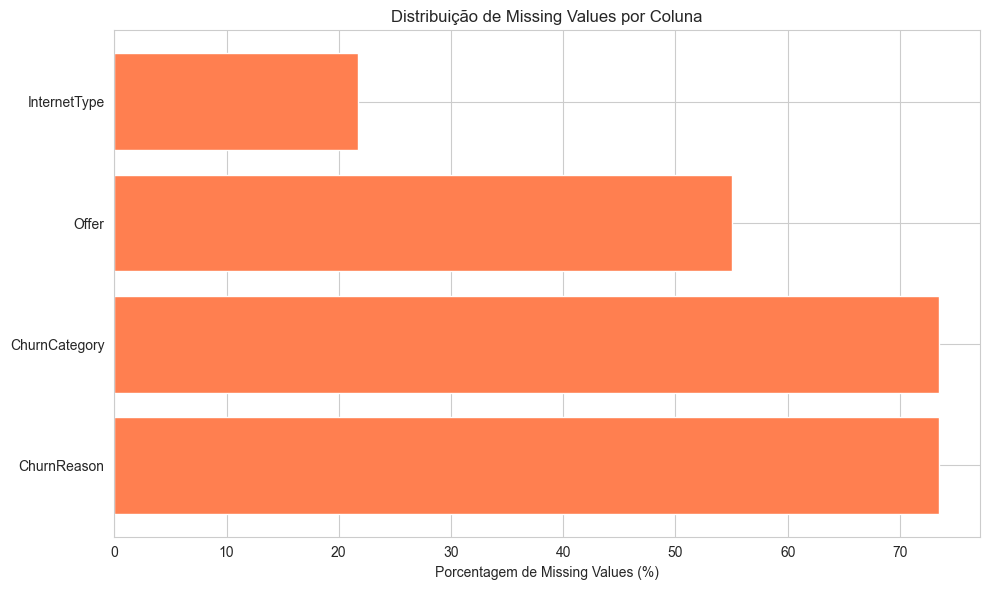

In [188]:

# Análise de valores ausentes
print("=== ANÁLISE DE MISSING VALUES ===\n")

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)
    
    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
    plt.xlabel('Porcentagem de Missing Values (%)')
    plt.title('Distribuição de Missing Values por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")


- Os valores ausentes são representados por `NaN` no DataFrame e são identificados usando `isnull()`.
- Podemos verificar a quantidade de valores ausentes por coluna usando `df.isnull().sum()`.
- Podemos verificar a porcentagem de valores ausentes por coluna usando `df.isnull().mean()`.

No dataset utilizado, há somente valores ausentes na coluna que define a razão do cancelamento - Churn Reason (73.46%) de valores ausentes. 
O dataset não possui valores ausentes em outras colunas e somente informações na coluna Churn Reason quando houve cancelamentos.


### 3.2 Análise da Variável Target

**Objetivo:** Entender a distribuição da variável alvo (balanceamento de classes)

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
target
0    5174
1    1869
Name: count, dtype: int64

Percentual:
Não cancelou (0): 73.46%
Cancelou (1): 26.54%


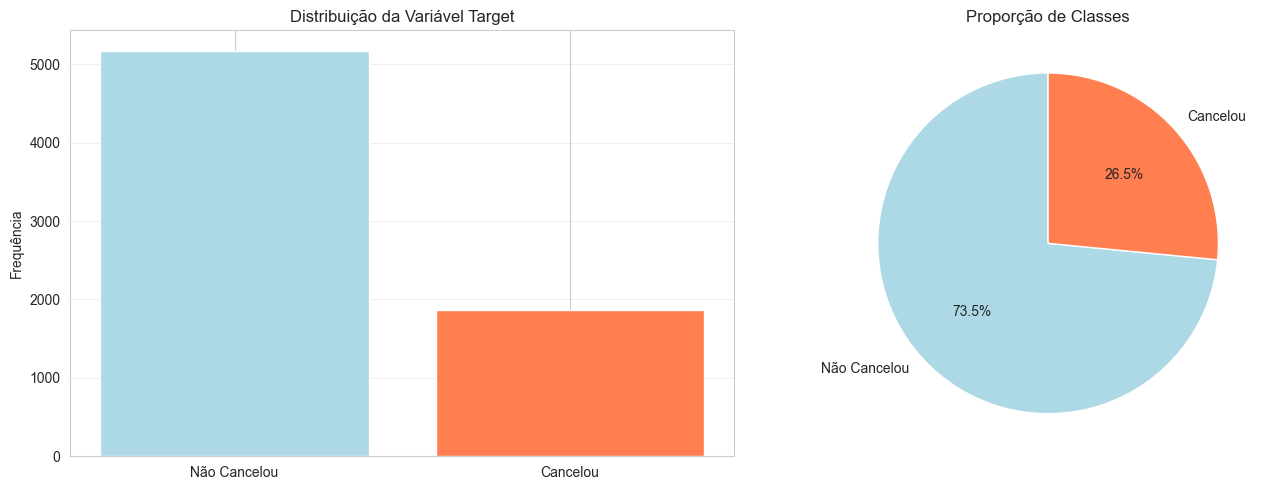


Ratio de balanceamento: 0.36
⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.


In [192]:
# Renomear variável `CurnValue` para `target`
#df_backup = df
df.rename(columns={'ChurnValue':'target'}, inplace=True)
df['target'].value_counts()

# Converter target para binário (0 = não cancelou, 1 = cancelou)
# No dataset original, valores > 0 indicam presença de cancelamento 
df['target'] = (df['target'] > 0).astype(int)

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)
print("\nPercentual:")
for idx, pct in target_percentages.items():
    label = "Não cancelou" if idx == 0 else "Cancelou"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['Não Cancelou', 'Cancelou'], target_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['Não Cancelou', 'Cancelou'], 
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("✓ Dataset razoavelmente balanceado.")

A variável alvo (target) indica se há presença (1) ou ausência (0) de cancelamentos de contratos. Na visualização, vemos 1869 casos “cencelou” (26,54%) e 5174 “não cencelou” (73,46%), o que mostra predominância da classe negativa (não cancelou); o ratio entre as classes é de aproximadamente 0,36, indicando um desbalanceamento. Isso significa que podemos seguir com modelos base sem grandes ajustes, mas é importante acompanhar métricas além da acurácia, como F1, precisão e recall, e observar a matriz de confusão para entender os erros. Para manter a proporção das classes nas amostras, use divisão estratificada; se necessário, técnicas como class_weight ou SMOTE podem ser testadas.

### 3.3 Análise de Outliers

**Objetivo:** Identificar valores extremos que podem ser erros de medição ou casos especiais

**Métodos utilizados:**
- **Z-Score**: Identifica valores que estão a mais de 3 desvios padrão da média
- **Visualização**: Boxplots para identificação visual de outliers
- **Remoção**: Remover valores extremos que não são considerados outliers

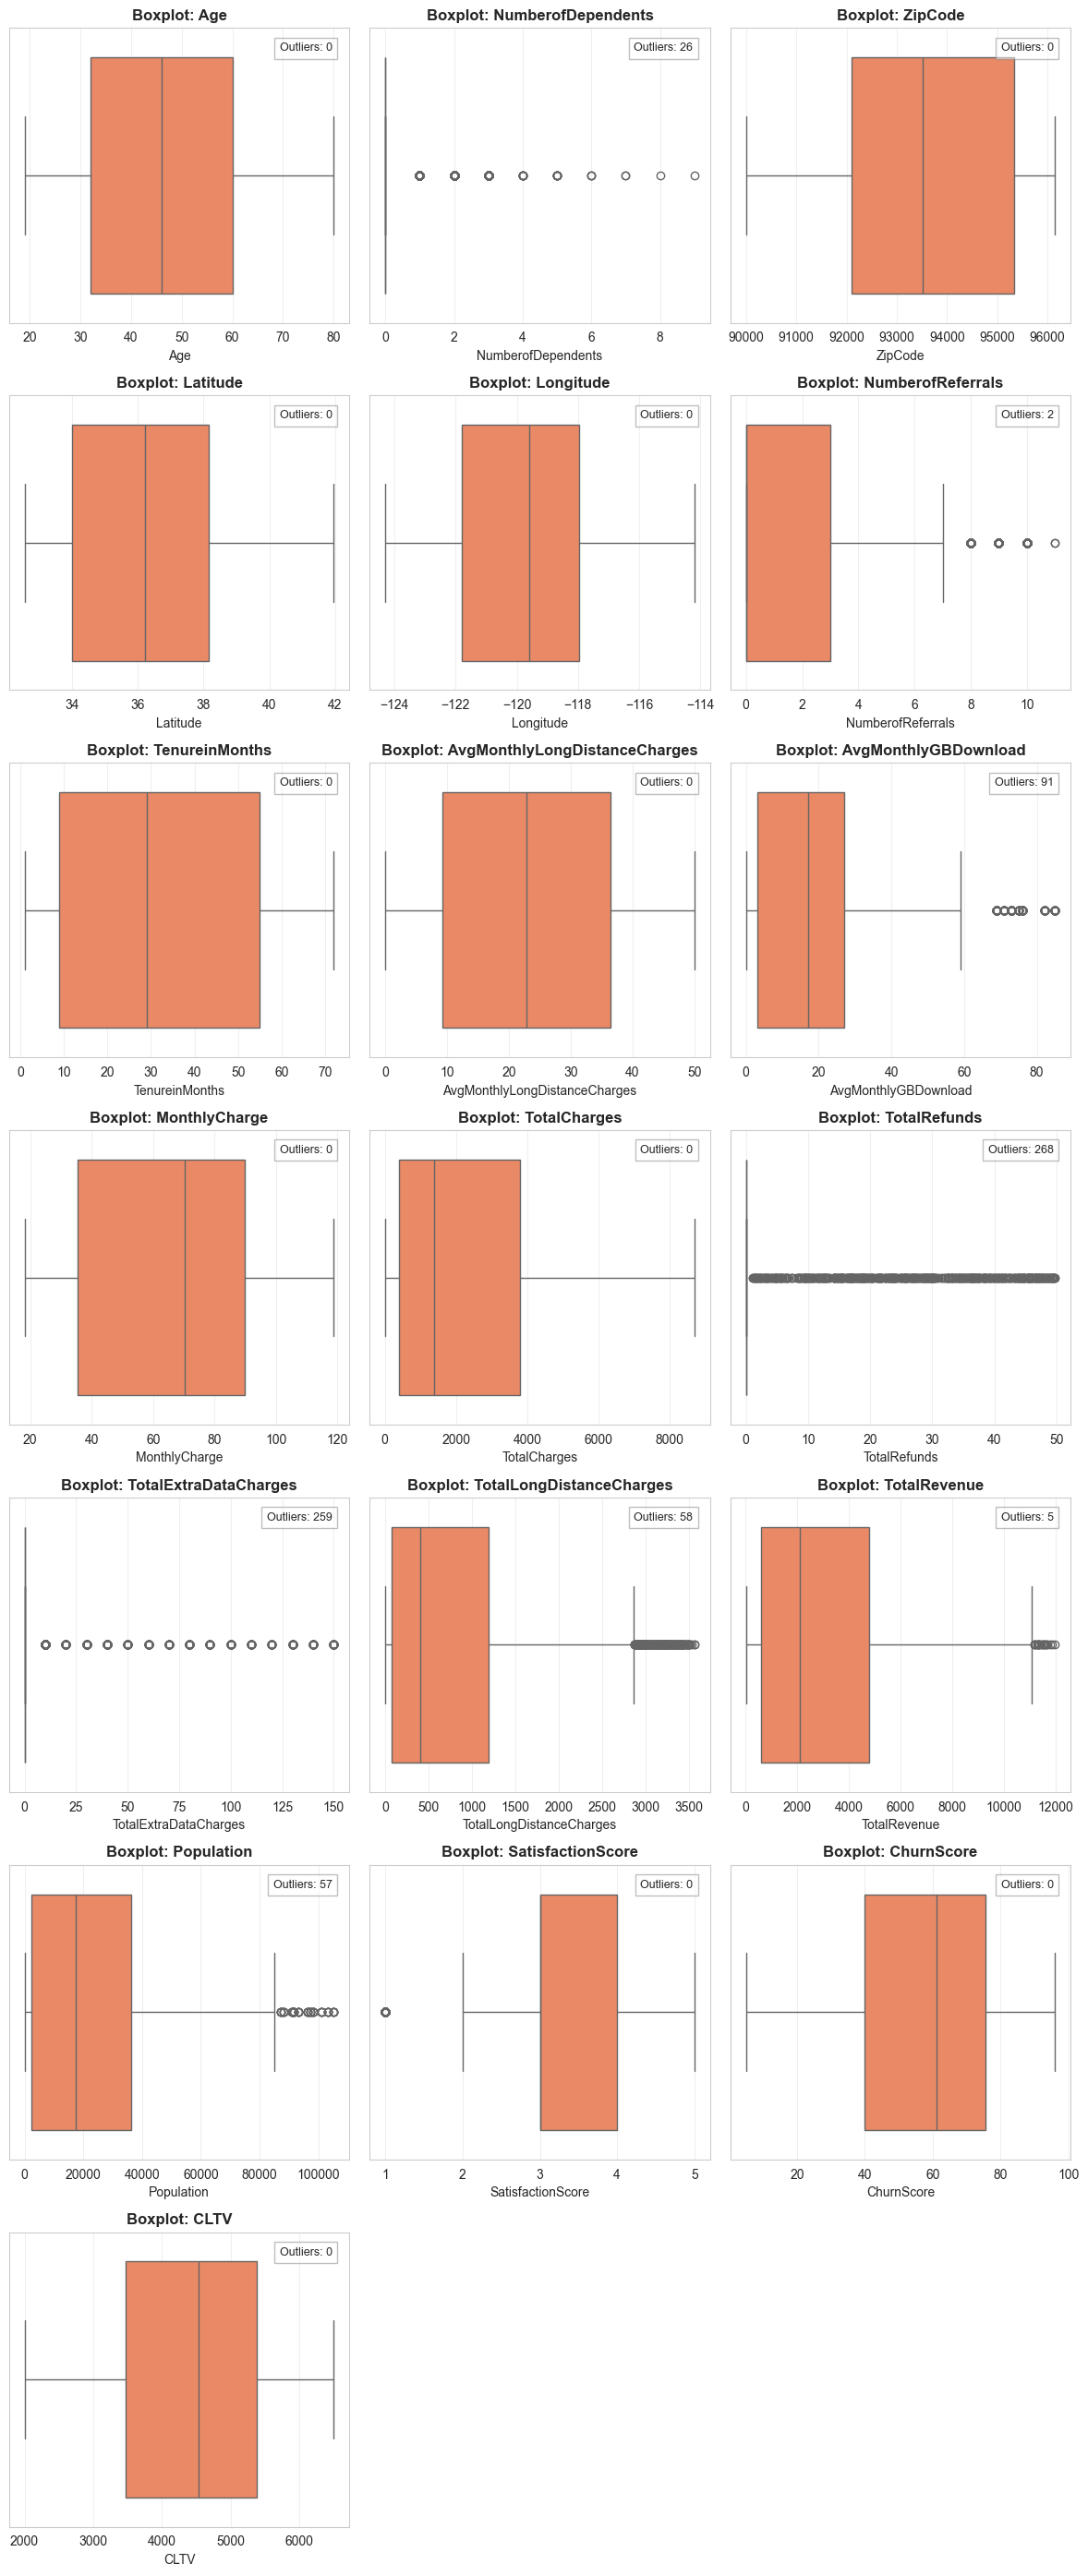

In [193]:
# Colunas numéricas (excluindo target)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['target'])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


### Interpretação dos Resultados: Outliers via Z-Score e Boxplot
- **Boxplot:** Permite visualizar rapidamente valores extremos em cada variável. Outliers aparecem como pontos fora dos limites do gráfico.
- **Z-Score:** Mede o quão distante cada valor está da média. Valores com z-score > 3 são considerados outliers estatísticos.

**Resultados:**  
A maioria das variáveis apresenta poucos outliers, tanto pelo boxplot quanto pelo z-score. Por exemplo, `CLTV` não possui outliers estatísticos (z-score > 3) e o boxplot não mostra pontos extremos.

**Conclusão:**  
Os dados estão bem distribuídos, sem outliers. Se houver outiliers, técnicas simples como capping são suficientes para tratamento, sem necessidade de remoção agressiva.


### 3.4 Análise de Anomalias e Valores Inválidos

**Objetivo:** Identificar valores que não fazem sentido no contexto do problema.

In [208]:
print("=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===\n")

# Verificações de consistência baseadas em conhecimento de domínio
anomalies = []
df.info()
# 1. Idade (deve estar entre 0 e 120)
for col in df.columns:
    print(col)
    
age_anomalies = df[(df['Age'] < 0) | (df['Age'] > 120)]
if len(age_anomalies) > 0:
    anomalies.append(f"Idade fora do intervalo válido: {len(age_anomalies)} casos")

# SatisfactionScore | int | Nota de satisfação | 1–5 |
SScore_anomalies = df[(df['SatisfactionScore'] < 1) | (df['SatisfactionScore'] > 5)]
if len(SScore_anomalies) > 0:
    anomalies.append(f"Score fora do intervalo válido: {len(SScore_anomalies)} casos")

# Offer | string | Última oferta aceita | None, Offer A–E |
Offer_anomalies = df[~df['Offer'].isin(['Offer A','Offer B','Offer C','Offer D','Offer E','None',np.nan,'na'])]
if len(Offer_anomalies) > 0:
    anomalies.append(f"Ofertas inválidas: {len(Offer_anomalies)} casos")
    print(f"⚠️ Ofertas anormais detectadas: {len(Offer_anomalies)} casos")

# InternetService | string | Tipo de internet | DSL, Fiber, Cable |
InternetService_anomalies = df[~df['InternetType'].isin(['Cable','DSL','Fiber Optic',np.nan,'na'])]
if len(InternetService_anomalies) > 0:
    anomalies.append(f"Tipo de internet inválido: {len(InternetService_anomalies)} casos")
    print(f"⚠️ Tipo de internet anormais detectadas: {len(InternetService_anomalies)} casos")

# PaymentMethod | string | Forma de pagamento | Bank, Card, Check |
PaymentMethod_anomalies = df[~df['PaymentMethod'].isin(['Bank Withdrawal','Credit Card','Mailed Check',np.nan,'na'])]
if len(PaymentMethod_anomalies) > 0:
    anomalies.append(f"Forma de pagamento inválido: {len(PaymentMethod_anomalies)} casos")
    print(f"⚠️ Forma de pagamento anormais detectadas: {len(PaymentMethod_anomalies)} casos")

# OnlineSecurity | boolean | Segurança online | Yes, No |
# OnlineBackup | boolean | Backup online | Yes, No |
# DeviceProtectionPlan | boolean | Proteção de dispositivos | Yes, No |
# PremiumTechSupport | boolean | Suporte premium | Yes, No |
# SeniorCitizen | boolean | Cliente tem 65 anos ou mais | Yes, No |
# Married | boolean | Cliente é casado | Yes, No |
# Dependents | boolean | Possui dependentes | Yes, No |
# ReferredAFriend | boolean | Indicou alguém | Yes, No |
# PhoneService | boolean | Telefone fixo | Yes, No |
# MultipleLines | boolean | Múltiplas linhas | Yes, No |
# StreamingTV | boolean | Streaming de TV | Yes, No |
# StreamingMovies | boolean | Streaming de filmes | Yes, No |
# StreamingMusic | boolean | Streaming de música | Yes, No |
# UnlimitedData | boolean | Dados ilimitados | Yes, No |
# PaperlessBilling | boolean | Fatura digital | Yes, No |
# ChurnLabel | boolean | Indicador de churn | Yes, No |

boolean_checks = {
    'OnlineSecurity': [0, 1],
    'OnlineBackup': [0, 1],
    'DeviceProtectionPlan': [0, 1],
    'PremiumTechSupport': [0, 1],
    'SeniorCitizen': [0, 1],
    'Married': [0, 1],
    'Dependents': [0, 1],
    'ReferredAFriend': [0, 1],
    'PhoneService': [0, 1],
    'MultipleLines': [0, 1],
    'StreamingTV': [0, 1],
    'StreamingMovies': [0, 1],
    'StreamingMusic': [0, 1],
    'UnlimitedData': [0, 1],
    'PaperlessBilling': [0, 1],
    'ChurnLabel': [0, 1]
}

for col, valid_values in boolean_checks.items():
    if col in df.columns:
        invalid = df[~df[col].map({"No": 0, "Yes": 1}).isin(valid_values) & df[col].notna()]
        if len(invalid) > 0:
            anomalies.append(f"{col}: {len(invalid)} valores inválidos")
            print(f"⚠️ {col}: {len(invalid)} valores fora do domínio esperado {valid_values}")

if len(anomalies) == 0:
    print("✓ Nenhuma anomalia óbvia detectada nas validações de domínio!")
else:
    print(f"\n📊 Total de tipos de anomalias detectadas: {len(anomalies)}")

# Verificar duplicados
duplicates = df.duplicated().sum()
print(f"\n=== DUPLICADOS ===")
print(f"Registros duplicados: {duplicates}")
if duplicates > 0:
    print("⚠️ Considere remover ou investigar registros duplicados")

=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     7043 non-null   object 
 1   Gender                         7043 non-null   object 
 2   Age                            7043 non-null   int64  
 3   Under30                        7043 non-null   object 
 4   SeniorCitizen                  7043 non-null   object 
 5   Married                        7043 non-null   object 
 6   Dependents                     7043 non-null   object 
 7   NumberofDependents             7043 non-null   int64  
 8   Country                        7043 non-null   object 
 9   State                          7043 non-null   object 
 10  City                           7043 non-null   object 
 11  ZipCode                        7043 non-null   int64  
 12